### Plotting correlation results from previous script

In [1]:
import pickle
import pandas as pd
import numpy as np
from scipy.stats import pearsonr, spearmanr

final_df= pd.read_pickle('final_df3.pkl') # final_df2 with weighted NAO values and new variables (wind comp + ssrd); final_df3 with the EA
print(final_df.columns)
print(final_df)

Index(['Year', 'Temp_DJF', 'Precip_DJF', 'Temp_MJJAS', 'Precip_MJJAS',
       'GlacierId', 'Glacier', 'Bs', 'Bw', 'Ba', 'Region', 'Cumulative_Ba',
       'Rolling_Bs', 'Rolling_Bw', 'Period', 'PC1_DJF', 'PC1_MJJAS', 'PC1_AO',
       'SSRD_DJF', 'SSRD_MJJAS', 'u10_DJF', 'u10_MJJAS', 'v10_DJF',
       'v10_MJJAS', 'NAO_Hurell', 'GlacierShort', 'EA_DJF', 'EA_MJJAS'],
      dtype='object')
     Year  Temp_DJF  Precip_DJF  Temp_MJJAS  Precip_MJJAS  GlacierId  \
0    1951 -4.362798    6.185266    9.747061     10.721021     2636.0   
1    1952 -2.419369    8.807426    9.220020     12.433246     2636.0   
2    1953 -5.094279    7.743274   10.786901     11.524487     2636.0   
3    1954 -3.825318    5.963656   10.494399     12.956203     2636.0   
4    1955 -4.074505    7.468448    9.956315      9.585814     2636.0   
..    ...       ...         ...         ...           ...        ...   
545  2022 -2.855950    9.078746   11.289492     13.741344     2768.0   
546  2022 -2.855950    9.078746   1

In [ ]:
# (IF NEEDED) to correct the polarity of signal after computing final df again with weighted NAO
final_df['PC1_DJF']= -final_df['PC1_DJF']
final_df['PC1_MJJAS']= -final_df['PC1_MJJAS']

### MB Component-wise (Bw) heat-map:

In [2]:
climate_map= {
    'North': {
        'Bw': ['PC1_AO', 'Temp_DJF', 'Precip_DJF', 'u10_DJF', 'v10_DJF', 'SSRD_DJF'],
        'Bs': ['Temp_MMJAS', 'Precip_MMJAS', 'u10_MMJAS', 'v10_MMJAS', 'SSRD_MMJAS'], 
        'Ba': ['PC1_AO', 'Temp_DJF', 'Precip_DJF', 'Temp_MMJAS', 'Precip_MMJAS', 'SSRD_MMJAS']
    },
    'South': {
        'Bw': ['PC1_DJF', 'EA_DJF', 'Temp_DJF', 'Precip_DJF',  'u10_DJF', 'v10_DJF', 'SSRD_DJF'],
        'Bs': ['Temp_MMJAS', 'Precip_MMJAS', 'u10_MMJAS', 'v10_MMJAS', 'SSRD_MMJAS'], 
        'Ba': ['PC1_DJF', 'EA_DJF', 'Temp_DJF', 'Precip_DJF', 'Temp_MMJAS', 'Precip_MMJAS', 'SSRD_MMJAS']
    },
}

In [2]:
mb_vars= ['Bw']
periods= ['Before_2000', 'After_2000']
glaciers= final_df['Glacier'].unique()
climate_map= {
    'North': {
        'Bw': ['PC1_AO', 'Temp_DJF', 'Precip_DJF', 'u10_DJF', 'v10_DJF', 'SSRD_DJF']
    },
    'South': {
        'Bw': ['PC1_DJF', 'Temp_DJF', 'Precip_DJF',  'u10_DJF', 'v10_DJF', 'SSRD_DJF']
    },
}
results= []

In [3]:
for glacier in glaciers:
    region= final_df.loc[final_df['Glacier'] == glacier, 'Region'].iloc[0] # iloc[0] is to select one region value per glacier as multiple rows of same g will have same region

    for period in periods:
        sub_df= final_df[(final_df['Glacier'] == glacier) & (final_df['Period'] == period)]

        for mb in mb_vars:
            clim_vars= climate_map[region][mb]

            for clim in clim_vars:
                df_clean= sub_df[[mb, clim]].dropna()

                if len(df_clean) >= 10:
                    r, p= pearsonr(df_clean[mb], df_clean[clim])
                else:
                    r, p= None, None

                results.append({
                'Glacier': glacier,
                'Region': region,
                'Period': period.replace("_", " "),
                'MB': mb,
                'Variable': clim,
                'r': r,
                'p': p,
                'n': len(df_clean),
                'text_color': 'red' if p is not None and p > 0.05 else 'black'
                })

In [4]:
cor_df= pd.DataFrame(results)
var_map= {
    'PC1_DJF': 'NAO',
    'PC1_AO': 'AO',
    'Temp_DJF': 'T(acc)',
    'Precip_DJF': 'P (acc)',
    'Temp_MJJAS': 'T (abl)',
    'Precip_MJJAS': 'P (abl)',
    'u10_DJF': 'u10 (acc)',
    'v10_DJF': 'v10 (acc)',
    'SSRD_DJF': 'SSRD (acc)'
    
}
cor_df['Variable']= cor_df['Variable'].replace(var_map)

# sorting glaciers

cor_df['Glacier']= pd.Categorical(
    cor_df['Glacier'],
    categories= sorted(cor_df['Glacier'].unique()),
    ordered= True
)
print(cor_df)

              Glacier Region       Period  MB    Variable         r  \
0           Storbreen  South  Before 2000  Bw         NAO  0.528977   
1           Storbreen  South  Before 2000  Bw      T(acc)  0.439499   
2           Storbreen  South  Before 2000  Bw     P (acc)  0.737504   
3           Storbreen  South  Before 2000  Bw   u10 (acc)  0.400096   
4           Storbreen  South  Before 2000  Bw   v10 (acc)  0.250113   
..                ...    ...          ...  ..         ...       ...   
127  Langfjordjokelen  North   After 2000  Bw      T(acc)  0.022800   
128  Langfjordjokelen  North   After 2000  Bw     P (acc)  0.239201   
129  Langfjordjokelen  North   After 2000  Bw   u10 (acc)  0.184441   
130  Langfjordjokelen  North   After 2000  Bw   v10 (acc) -0.277542   
131  Langfjordjokelen  North   After 2000  Bw  SSRD (acc) -0.137761   

                p   n text_color  
0    9.323565e-05  49      black  
1    1.580133e-03  49      black  
2    1.500691e-09  49      black  
3    4.

In [19]:
print(cor_df.Glacier.unique())

['Storbreen', 'Grasubreen', 'Hellstugubreen', 'Nigardsbreen', 'Alfotbreen', ..., 'Grafjellsbrea', 'Engabreen', 'Hansebreen', 'Austdalsbreen', 'Langfjordjokelen']
Length: 11
Categories (11, object): ['Alfotbreen' < 'Austdalsbreen' < 'Engabreen' < 'Grafjellsbrea' ... 'Langfjordjokelen' < 'Nigardsbreen' < 'Rembesdalskåka' < 'Storbreen']


In [ ]:
# Temporarily display full content
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(cor_df)


In [5]:
## Creating short form dictinary for glacier names

glacier_shortnames = {'Alfotbreen': 'Alf', 
                        'Austdalsbreen': 'Aus', 
                        'Engabreen': 'Eng', 
                        'Grafjellsbrea': 'Graf', 
                        'Grasubreen': 'Gras', 
                        'Hansebreen': 'Han', 
                        'Hellstugubreen': 'Hell', 
                        'Langfjordjokelen': 'Lan',
                        'Nigardsbreen': 'Nig', 
                        'Rembesdalskåka': 'Rem', 
                        'Storbreen': 'Sto'}


### Code to plot one Bw ~ one period (before 2000)

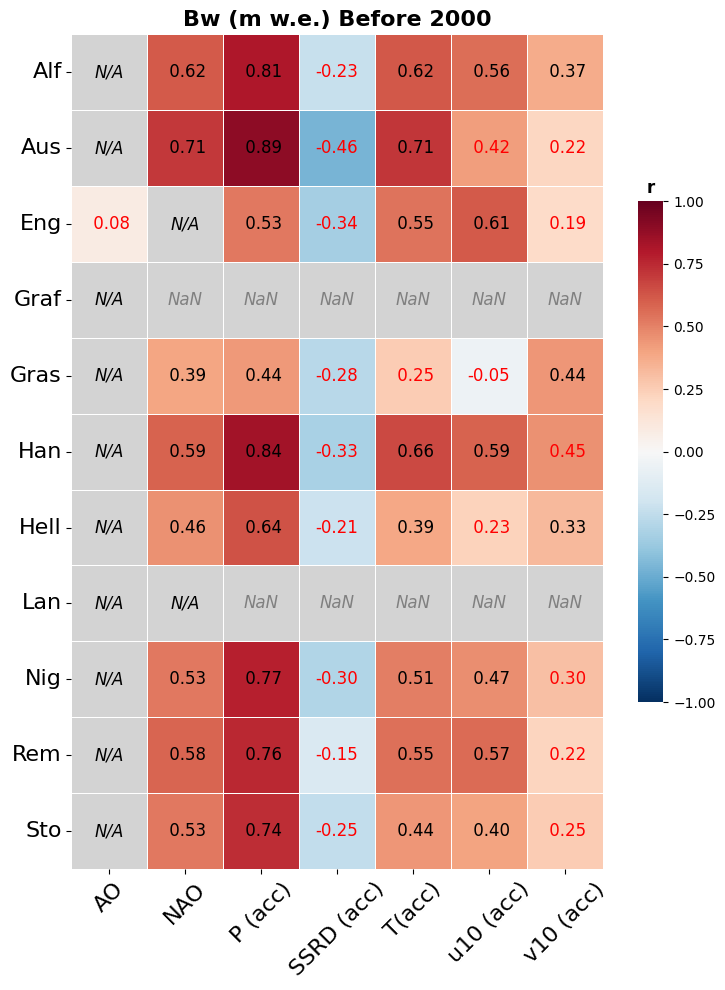

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

cmap= matplotlib.colormaps['RdBu_r'].copy()
cmap.set_bad('lightgrey')   # to set an NA value as grey

mb= 'Bw'
period= 'Before 2000'
gridline_color = "#d3d3d3"  # light grey

subset = cor_df[(cor_df['MB'] == mb) & (cor_df['Period'] == period)].copy()
heat_data = subset.pivot(index='Glacier', columns='Variable', values='r')
heat_data.index = heat_data.index.map(glacier_shortnames) # for using short glacier names in heatmap
mask = heat_data.isnull()

fig, ax = plt.subplots(figsize=(8, 10))


sns.heatmap(
    heat_data,
    cmap=cmap,
    #annot= heat_data.round(2), # r val upto 2 dec places
    #fmt= '.2f', # format
    linewidth= 0.5, # lines bw the cells
    linecolor= 'white',
    square= True,
    mask= mask, # no text on NA cells
    cbar= True,
    cbar_kws= {
        'shrink': 0.6,       # Shrink the colorbar height to 50%
        'aspect': 20,        # Thinner colorbar (higher = thinner)
        'pad': 0.05,         # Padding between heatmap and colorbar
    },                       # 'label': 'r', if u want label on the side
    vmin= -1, vmax= 1,
    ax=ax
)
    

# for color in r values
text_colors= subset.pivot(index='Glacier', columns='Variable', values='text_color')
text_colors.index = text_colors.index.map(glacier_shortnames)

for y in range(heat_data.shape[0]):
   for x in range(heat_data.shape[1]):
       r_val = heat_data.iloc[y, x]
       col_name = heat_data.columns[x]
       row_name = heat_data.index[y] 

       if pd.notna(r_val):
           color = text_colors.iloc[y, x]
           ax.text(x + 0.5, y + 0.5, f"{r_val: .2f}",
                   ha='center', va='center', color=color, fontsize=12)
       elif col_name == 'AO':
           ax.text(x + 0.5, y + 0.5, "N/A",
                   ha='center', va='center', color='black', fontsize=12, style='italic')
       elif col_name == 'NAO' and row_name in ['Eng', 'Lan']:
           ax.text(x + 0.5, y + 0.5, "N/A",
                   ha='center', va='center', color='black', fontsize=12, style='italic')
       elif pd.isna(r_val):
           ax.text(x + 0.5, y + 0.5, "NaN",
                   ha='center', va='center', color='gray', fontsize=12, style='italic')
    
cbar = ax.collections[0].colorbar  # gets the colorbar object
cbar.ax.set_title('r', fontsize=12, weight='bold', pad=6, loc='center')

ax.set_title(f"{mb} (m w.e.) {period}", fontsize=16, weight='bold')
ax.set_ylabel('')
ax.set_xlabel('')
ax.tick_params(axis='y', labelsize=16)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, ha='right', fontsize=16)
ax.tick_params(axis='x', labelsize=16, rotation=45)

plt.tight_layout()
#plt.savefig(r"C:\Users\danis\Desktop\Danish\Py-Plots\05_Correlation Plots\Correlation_matrix_Bw_Before2000.png", dpi=800, bbox_inches='tight')
plt.show()

### Code to plot one Bw ~ one period (after 2000)

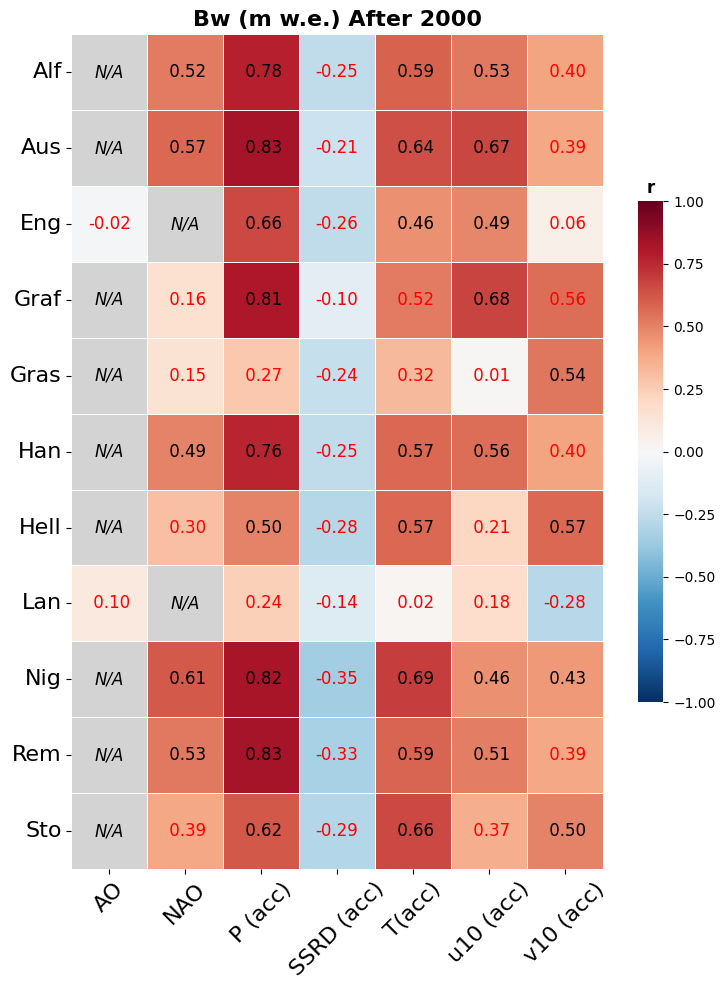

In [22]:
cmap= matplotlib.colormaps['RdBu_r'].copy()
cmap.set_bad('lightgrey')   # to set an NA value as grey

mb= 'Bw'
periods= 'After 2000'
gridline_color = "#d3d3d3"  # light grey

subset = cor_df[(cor_df['MB'] == mb) & (cor_df['Period'] == periods)].copy()
heat_data = subset.pivot(index='Glacier', columns='Variable', values='r')
heat_data.index = heat_data.index.map(glacier_shortnames) # for using short glacier names in heatmap

mask = heat_data.isnull()

fig, ax = plt.subplots(figsize=(8, 10))

sns.heatmap(
    heat_data,
    cmap=cmap,
    #annot= heat_data.round(2), # r val upto 2 dec places
    #fmt= '.2f', # format
    linewidth= 0.5, # lines bw the cells
    linecolor= 'white',
    square= True,
    mask= mask, # no text on NA cells
    cbar= True,
    cbar_kws= {
        'shrink': 0.6,       # Shrink the colorbar height to 50%
        'aspect': 20,        # Thinner colorbar (higher = thinner)
        'pad': 0.05,         # Padding between heatmap and colorbar
    },                       # 'label': 'r', if u want label on the side
    vmin= -1, vmax= 1,
    ax=ax
)
    

# for color in r values
text_colors= subset.pivot(index='Glacier', columns='Variable', values='text_color')
text_colors.index = text_colors.index.map(glacier_shortnames)

for y in range(heat_data.shape[0]):
   for x in range(heat_data.shape[1]):
       r_val = heat_data.iloc[y, x]
       col_name = heat_data.columns[x]
       row_name = heat_data.index[y] 

       if pd.notna(r_val):
           color = text_colors.iloc[y, x]
           ax.text(x + 0.5, y + 0.5, f"{r_val: .2f}",
                   ha='center', va='center', color=color, fontsize=12)
       elif col_name == 'AO':
           ax.text(x + 0.5, y + 0.5, "N/A",
                   ha='center', va='center', color='black', fontsize=12, style='italic')
       elif col_name == 'NAO' and row_name in ['Eng', 'Lan']:
           ax.text(x + 0.5, y + 0.5, "N/A",
                   ha='center', va='center', color='black', fontsize=12, style='italic')
       elif pd.isna(r_val):
           ax.text(x + 0.5, y + 0.5, "NaN",
                   ha='center', va='center', color='gray', fontsize=12, style='italic')
           
    
cbar = ax.collections[0].colorbar  # gets the colorbar object
cbar.ax.set_title('r', fontsize=12, weight='bold', pad=6, loc='center')

ax.set_title(f"{mb} (m w.e.) {periods}", fontsize=16, weight='bold')
ax.set_ylabel('')
ax.set_xlabel('')
ax.tick_params(axis='y', labelsize=16)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, ha='right', fontsize=16)
ax.tick_params(axis='x', labelsize=16, rotation=45)

plt.tight_layout()
#plt.savefig('Correlation_matrix_Bw_After2000.png', dpi=800, bbox_inches='tight')
#plt.savefig(r"C:\Users\danis\Desktop\Danish\Py-Plots\05_Correlation Plots\Correlation_matrix_Bw_After2000.png", dpi=800, bbox_inches='tight')
plt.show()

In [ ]:
#print(final_df.head())
#final_df.to_pickle('final_df.pkl')

In [7]:
glacier_name= 'Langfjordjokelen'
period= 'After_2000'
df_glacier= final_df[(final_df['Glacier'] == glacier_name) & (final_df['Period'] == period)]

r, p = pearsonr(df_glacier['Bw'], df_glacier['PC1_DJF'])
print(f"{glacier_name}: Bw ({period}) vs PC1_DJF correlation: r = {r:.3f}, p = {p:.3f}")

Langfjordjokelen: Bw (After_2000) vs PC1_DJF correlation: r = 0.138, p = 0.541


### MB Component-wise (Bs) heat-map:

In [23]:
mb_vars= ['Bs']
periods= ['Before_2000', 'After_2000']
glaciers= final_df['Glacier'].unique()
climate_map= {
    'North': {
       'Bs': ['Temp_MJJAS', 'Precip_MJJAS', 'SSRD_MJJAS'] 
    },
    'South': {
        'Bs': ['Temp_MJJAS', 'Precip_MJJAS', 'SSRD_MJJAS']
    },
}
results= []


for glacier in glaciers:
    region= final_df.loc[final_df['Glacier'] == glacier, 'Region'].iloc[0] # iloc[0] is to select one region value per glacier as multiple rows of same g will have same region

    for period in periods:
        sub_df= final_df[(final_df['Glacier'] == glacier) & (final_df['Period'] == period)]

        for mb in mb_vars:
            clim_vars= climate_map[region][mb]

            for clim in clim_vars:
                df_clean= sub_df[[mb, clim]].dropna()

                if len(df_clean) >= 10:
                    r, p= pearsonr(df_clean[mb], df_clean[clim])
                else:
                    r, p= None, None

                results.append({
                'Glacier': glacier,
                'Region': region,
                'Period': period.replace("_", " "),
                'MB': mb,
                'Variable': clim,
                'r': r,
                'p': p,
                'n': len(df_clean),
                'text_color': 'red' if p is not None and p > 0.05 else 'black'
                })


cor_df= pd.DataFrame(results)
var_map= {
    'Temp_MJJAS': 'T (abl)',
    'Precip_MJJAS': 'P (abl)',
    'u10_MJJAS': 'u10 (abl)',
    'v10_MJJAS': 'v10 (abl)',
    'SSRD_MJJAS': 'SSRD (abl)',
}

cor_df['Variable']= cor_df['Variable'].replace(var_map)

# sorting glaciers

cor_df['Glacier']= pd.Categorical(
    cor_df['Glacier'],
    categories= sorted(cor_df['Glacier'].unique()),
    ordered= True
)
print(cor_df)

             Glacier Region       Period  MB    Variable         r         p  \
0          Storbreen  South  Before 2000  Bs     T (abl) -0.586381  0.000010   
1          Storbreen  South  Before 2000  Bs     P (abl)  0.405928  0.003805   
2          Storbreen  South  Before 2000  Bs  SSRD (abl) -0.484090  0.000425   
3          Storbreen  South   After 2000  Bs     T (abl) -0.737034  0.000060   
4          Storbreen  South   After 2000  Bs     P (abl)  0.523393  0.010379   
..               ...    ...          ...  ..         ...       ...       ...   
61  Langfjordjokelen  North  Before 2000  Bs     P (abl)       NaN       NaN   
62  Langfjordjokelen  North  Before 2000  Bs  SSRD (abl)       NaN       NaN   
63  Langfjordjokelen  North   After 2000  Bs     T (abl) -0.675314  0.000407   
64  Langfjordjokelen  North   After 2000  Bs     P (abl)  0.067662  0.759034   
65  Langfjordjokelen  North   After 2000  Bs  SSRD (abl) -0.194820  0.373037   

     n text_color  
0   49      black  

### Code to plot Bs ~ one period (before 2000)

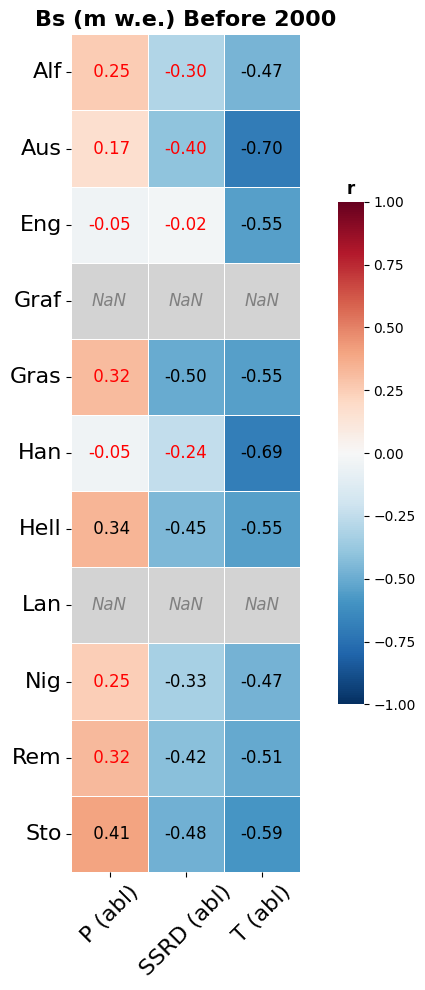

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

cmap= matplotlib.colormaps['RdBu_r'].copy()
cmap.set_bad('lightgrey')   # to set an NA value as grey

mb= 'Bs'
period= 'Before 2000'
gridline_color = "#d3d3d3"  # light grey

subset = cor_df[(cor_df['MB'] == mb) & (cor_df['Period'] == period)].copy()
heat_data = subset.pivot(index='Glacier', columns='Variable', values='r')
heat_data.index = heat_data.index.map(glacier_shortnames) # for using short glacier names in heatmap
mask = heat_data.isnull()

fig, ax = plt.subplots(figsize=(8, 10))


sns.heatmap(
    heat_data,
    cmap=cmap,
    #annot= heat_data.round(2), # r val upto 2 dec places
    #fmt= '.2f', # format
    linewidth= 0.5, # lines bw the cells
    linecolor= 'white',
    square= True,
    mask= mask, # no text on NA cells
    cbar= True,
    cbar_kws= {
        'shrink': 0.6,       # Shrink the colorbar height to 50%
        'aspect': 20,        # Thinner colorbar (higher = thinner)
        'pad': 0.05,         # Padding between heatmap and colorbar
    },                       # 'label': 'r', if u want label on the side
    vmin= -1, vmax= 1,
    ax=ax
)
    

# for color in r values
text_colors= subset.pivot(index='Glacier', columns='Variable', values='text_color')
text_colors.index = text_colors.index.map(glacier_shortnames)
for y in range(heat_data.shape[0]):
   for x in range(heat_data.shape[1]):
       r_val= heat_data.iloc[y, x]
       if pd.notna(r_val):
           color= text_colors.iloc[y, x]
           ax.text( x + 0.5, y + 0.5, f"{r_val: .2f}",
                   ha= 'center', va= 'center', color= color, fontsize= 12)
       elif pd.isna(r_val):
           ax.text(x + 0.5, y + 0.5, "NaN",
                   ha='center', va='center', color='gray', fontsize=12, style='italic')   
    
cbar = ax.collections[0].colorbar  # gets the colorbar object
cbar.ax.set_title('r', fontsize=12, weight='bold', pad=6, loc='center')

ax.set_title(f"{mb} (m w.e.) {period}", fontsize=16, weight='bold')
ax.set_ylabel('')
ax.set_xlabel('')
ax.tick_params(axis='y', labelsize=16)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, ha='right', fontsize=16)
ax.tick_params(axis='x', labelsize=16, rotation=45)

plt.tight_layout()
#plt.savefig('Correlation_matrix_Bs_Before2000.png', dpi=800, bbox_inches='tight')
#plt.savefig(r"C:\Users\danis\Desktop\Danish\Py-Plots\05_Correlation Plots\Correlation_matrix_Bs_Before2000.png", dpi=800, bbox_inches='tight')
plt.show()

### Code to plot Bs ~ one period (after 2000)

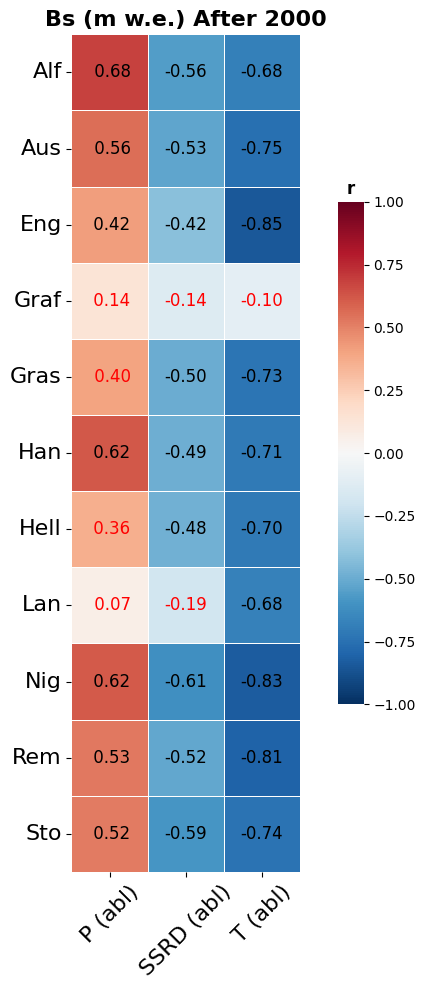

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

cmap= matplotlib.colormaps['RdBu_r'].copy()
cmap.set_bad('lightgrey')   # to set an NA value as grey

mb= 'Bs'
period= 'After 2000'
gridline_color = "#d3d3d3"  # light grey

subset = cor_df[(cor_df['MB'] == mb) & (cor_df['Period'] == period)].copy()
heat_data = subset.pivot(index='Glacier', columns='Variable', values='r')
heat_data.index = heat_data.index.map(glacier_shortnames) # for using short glacier names in heatmap

mask = heat_data.isnull()

fig, ax = plt.subplots(figsize=(8, 10))


sns.heatmap(
    heat_data,
    cmap=cmap,
    #annot= heat_data.round(2), # r val upto 2 dec places
    #fmt= '.2f', # format
    linewidth= 0.5, # lines bw the cells
    linecolor= 'white',
    square= True,
    mask= mask, # no text on NA cells
    cbar= True,
    cbar_kws= {
        'shrink': 0.6,       # Shrink the colorbar height to 50%
        'aspect': 20,        # Thinner colorbar (higher = thinner)
        'pad': 0.05,         # Padding between heatmap and colorbar
    },                       # 'label': 'r', if u want label on the side
    vmin= -1, vmax= 1,
    ax=ax
)
    

# for color in r values
text_colors= subset.pivot(index='Glacier', columns='Variable', values='text_color')
text_colors.index = text_colors.index.map(glacier_shortnames)

for y in range(heat_data.shape[0]):
   for x in range(heat_data.shape[1]):
       r_val= heat_data.iloc[y, x]
       if pd.notna(r_val):
           color= text_colors.iloc[y, x]
           ax.text( x + 0.5, y + 0.5, f"{r_val: .2f}",
                   ha= 'center', va= 'center', color= color, fontsize= 12)
           
    
cbar = ax.collections[0].colorbar  # gets the colorbar object
cbar.ax.set_title('r', fontsize=12, weight='bold', pad=6, loc='center')

ax.set_title(f"{mb} (m w.e.) {period}", fontsize=16, weight='bold')
ax.set_ylabel('')
ax.set_xlabel('')
ax.tick_params(axis='y', labelsize=16)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, ha='right', fontsize=16)
ax.tick_params(axis='x', labelsize=16, rotation=45)

plt.tight_layout()
#plt.savefig('Correlation_matrix_Bs_After2000.png', dpi=800, bbox_inches='tight')
#plt.savefig(r"C:\Users\danis\Desktop\Danish\Py-Plots\Presentation 0407\Correlation_matrix_Bs_After2000.png", dpi=800, bbox_inches='tight')
plt.show()

### MB Component-wise (Ba) heat-map:

In [29]:
mb_vars= ['Ba']
periods= ['Before_2000', 'After_2000']
glaciers= final_df['Glacier'].unique()
climate_map= {
    'North': {
       'Ba': ['PC1_AO', 'Temp_DJF', 'Precip_DJF', 'Temp_MJJAS', 'Precip_MJJAS', 'SSRD_MJJAS'] 
    },
    'South': {
        'Ba': ['PC1_DJF', 'Temp_DJF', 'Precip_DJF', 'Temp_MJJAS', 'Precip_MJJAS', 'SSRD_MJJAS']
    },
}
results= []


for glacier in glaciers:
    region= final_df.loc[final_df['Glacier'] == glacier, 'Region'].iloc[0] # iloc[0] is to select one region value per glacier as multiple rows of same g will have same region

    for period in periods:
        sub_df= final_df[(final_df['Glacier'] == glacier) & (final_df['Period'] == period)]

        for mb in mb_vars:
            clim_vars= climate_map[region][mb]

            for clim in clim_vars:
                df_clean= sub_df[[mb, clim]].dropna()

                if len(df_clean) >= 10:
                    r, p= pearsonr(df_clean[mb], df_clean[clim])
                else:
                    r, p= None, None

                results.append({
                'Glacier': glacier,
                'Region': region,
                'Period': period.replace("_", " "),
                'MB': mb,
                'Variable': clim,
                'r': r,
                'p': p,
                'n': len(df_clean),
                'text_color': 'red' if p is not None and p > 0.05 else 'black'
                })


cor_df= pd.DataFrame(results)
var_map= {
    'PC1_DJF': 'NAO',
    'PC1_AO': 'AO',
    'Temp_DJF': 'T (acc)',
    'Precip_DJF': 'P (acc)',
    'Temp_MJJAS': 'T (abl)',
    'Precip_MJJAS': 'P (abl)',
    'SSRD_MJJAS': 'SSRD (abl)',
}
    #'u10_MJJAS': 'u10 (abl)',
    #'v10_MJJAS': 'v10 (abl)',
#}

cor_df['Variable']= cor_df['Variable'].replace(var_map)

# sorting glaciers

cor_df['Glacier']= pd.Categorical(
    cor_df['Glacier'],
    categories= sorted(cor_df['Glacier'].unique()),
    ordered= True
)
print(cor_df)

              Glacier Region       Period  MB    Variable         r         p  \
0           Storbreen  South  Before 2000  Ba         NAO  0.459439  0.000897   
1           Storbreen  South  Before 2000  Ba     T (acc)  0.376492  0.007669   
2           Storbreen  South  Before 2000  Ba     P (acc)  0.605921  0.000004   
3           Storbreen  South  Before 2000  Ba     T (abl) -0.380988  0.006918   
4           Storbreen  South  Before 2000  Ba     P (abl)  0.283926  0.048034   
..                ...    ...          ...  ..         ...       ...       ...   
127  Langfjordjokelen  North   After 2000  Ba     T (acc)  0.406988  0.053932   
128  Langfjordjokelen  North   After 2000  Ba     P (acc)  0.442710  0.034388   
129  Langfjordjokelen  North   After 2000  Ba     T (abl) -0.585158  0.003356   
130  Langfjordjokelen  North   After 2000  Ba     P (abl)  0.066522  0.762979   
131  Langfjordjokelen  North   After 2000  Ba  SSRD (abl) -0.056867  0.796621   

      n text_color  
0    4

### Code to plot Ba ~ one period (before 2000)

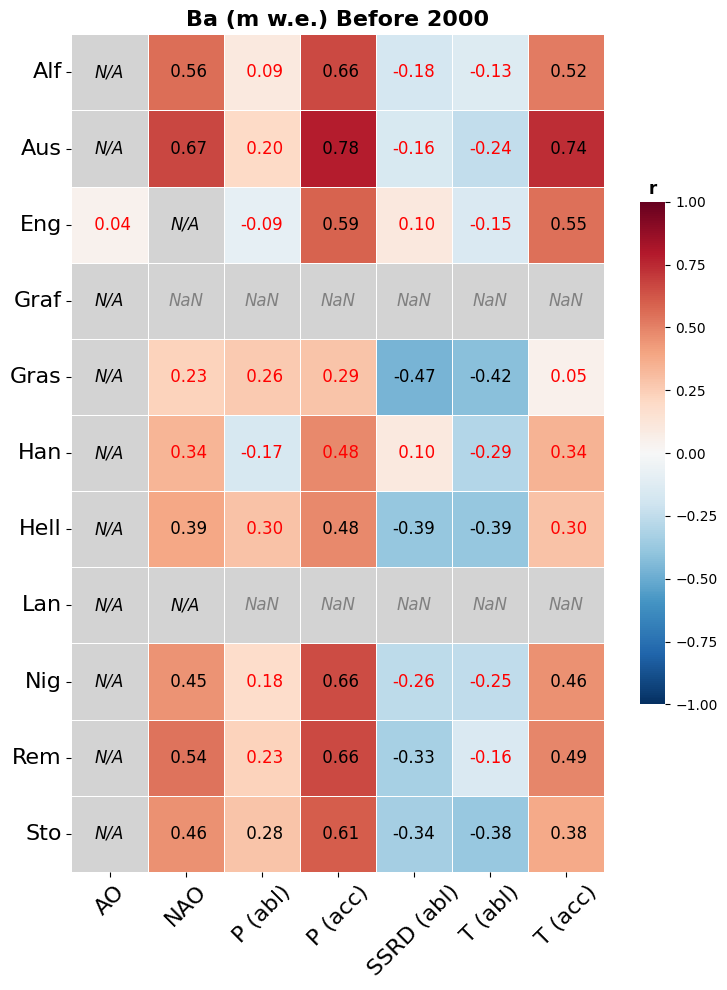

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

cmap= matplotlib.colormaps['RdBu_r'].copy()
cmap.set_bad('lightgrey')   # to set an NA value as grey

mb= 'Ba'
period= 'Before 2000'
gridline_color = "#d3d3d3"  # light grey

subset = cor_df[(cor_df['MB'] == mb) & (cor_df['Period'] == period)].copy()
heat_data = subset.pivot(index='Glacier', columns='Variable', values='r')
heat_data.index = heat_data.index.map(glacier_shortnames) # for using short glacier names in heatmap
mask = heat_data.isnull()

fig, ax = plt.subplots(figsize=(8, 10))


sns.heatmap(
    heat_data,
    cmap=cmap,
    #annot= heat_data.round(2), # r val upto 2 dec places
    #fmt= '.2f', # format
    linewidth= 0.5, # lines bw the cells
    linecolor= 'white',
    square= True,
    mask= mask, # no text on NA cells
    cbar= True,
    cbar_kws= {
        'shrink': 0.6,       # Shrink the colorbar height to 50%
        'aspect': 20,        # Thinner colorbar (higher = thinner)
        'pad': 0.05,         # Padding between heatmap and colorbar
    },                       # 'label': 'r', if u want label on the side
    vmin= -1, vmax= 1,
    ax=ax
)
    

# for color in r values
text_colors= subset.pivot(index='Glacier', columns='Variable', values='text_color')
text_colors.index = text_colors.index.map(glacier_shortnames)

for y in range(heat_data.shape[0]):
   for x in range(heat_data.shape[1]):
       r_val = heat_data.iloc[y, x]
       col_name = heat_data.columns[x]
       row_name = heat_data.index[y] 

       if pd.notna(r_val):
           color = text_colors.iloc[y, x]
           ax.text(x + 0.5, y + 0.5, f"{r_val: .2f}",
                   ha='center', va='center', color=color, fontsize=12)
       elif col_name == 'AO':
           ax.text(x + 0.5, y + 0.5, "N/A",
                   ha='center', va='center', color='black', fontsize=12, style='italic')
       elif col_name == 'NAO' and row_name in ['Eng', 'Lan']:
           ax.text(x + 0.5, y + 0.5, "N/A",
                   ha='center', va='center', color='black', fontsize=12, style='italic')
       elif pd.isna(r_val):
           ax.text(x + 0.5, y + 0.5, "NaN",
                   ha='center', va='center', color='gray', fontsize=12, style='italic')
           
    
cbar = ax.collections[0].colorbar  # gets the colorbar object
cbar.ax.set_title('r', fontsize=12, weight='bold', pad=6, loc='center')

ax.set_title(f"{mb} (m w.e.) {period}", fontsize=16, weight='bold')
ax.set_ylabel('')
ax.set_xlabel('')
ax.tick_params(axis='y', labelsize=16)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, ha='right', fontsize=16)
ax.tick_params(axis='x', labelsize=16, rotation=45)

plt.tight_layout()
#plt.savefig('Correlation_matrix_Ba_Before2000.png', dpi=800, bbox_inches='tight')
#plt.savefig(r"C:\Users\danis\Desktop\Danish\Py-Plots\05_Correlation Plots\Correlation_matrix_Ba_Before2000.png", dpi=800, bbox_inches='tight')
plt.show()

### Code to plot Ba ~ one period (after 2000)

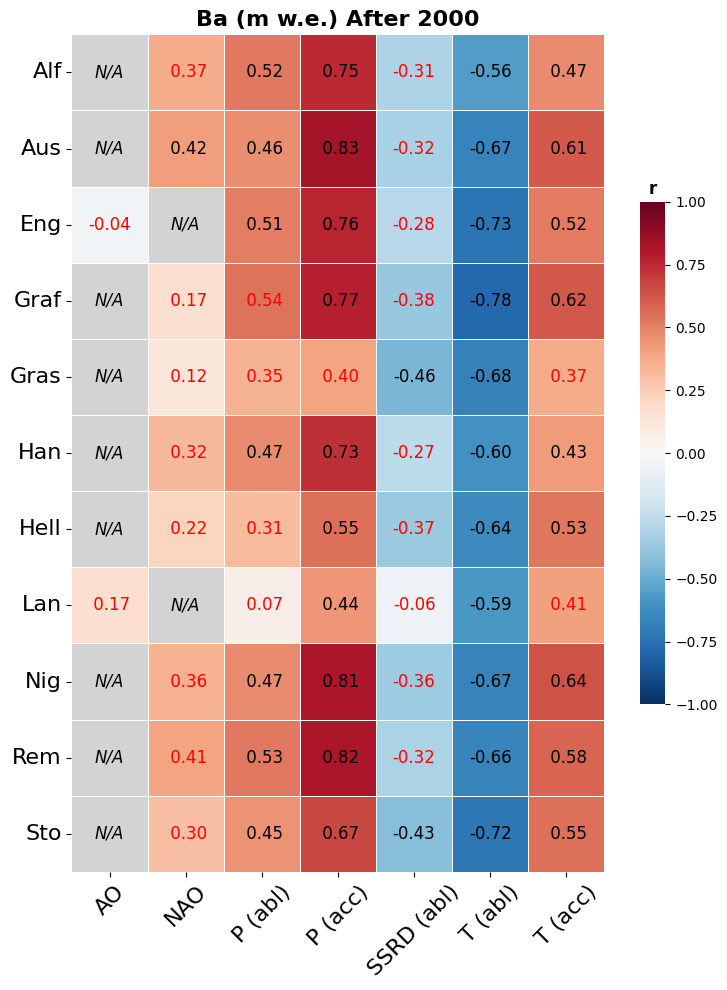

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

cmap= matplotlib.colormaps['RdBu_r'].copy()
cmap.set_bad('lightgrey')   # to set an NA value as grey

mb= 'Ba'
period= 'After 2000'
gridline_color = "#d3d3d3"  # light grey

subset = cor_df[(cor_df['MB'] == mb) & (cor_df['Period'] == period)].copy()
heat_data = subset.pivot(index='Glacier', columns='Variable', values='r')
heat_data.index = heat_data.index.map(glacier_shortnames) # for using short glacier names in heatmap

mask = heat_data.isnull()

fig, ax = plt.subplots(figsize=(8, 10))


sns.heatmap(
    heat_data,
    cmap=cmap,
    #annot= heat_data.round(2), # r val upto 2 dec places
    #fmt= '.2f', # format
    linewidth= 0.5, # lines bw the cells
    linecolor= 'white',
    square= True,
    mask= mask, # no text on NA cells
    cbar= True,
    cbar_kws= {
        'shrink': 0.6,       # Shrink the colorbar height to 50%
        'aspect': 20,        # Thinner colorbar (higher = thinner)
        'pad': 0.05,         # Padding between heatmap and colorbar
    },                       # 'label': 'r', if u want label on the side
    vmin= -1, vmax= 1,
    ax=ax
)
    

# for color in r values
text_colors= subset.pivot(index='Glacier', columns='Variable', values='text_color')
text_colors.index = text_colors.index.map(glacier_shortnames)

for y in range(heat_data.shape[0]):
   for x in range(heat_data.shape[1]):
       r_val = heat_data.iloc[y, x]
       col_name = heat_data.columns[x]
       row_name = heat_data.index[y] 

       if pd.notna(r_val):
           color = text_colors.iloc[y, x]
           ax.text(x + 0.5, y + 0.5, f"{r_val: .2f}",
                   ha='center', va='center', color=color, fontsize=12)
       elif col_name == 'AO':
           ax.text(x + 0.5, y + 0.5, "N/A",
                   ha='center', va='center', color='black', fontsize=12, style='italic')
       elif col_name == 'NAO' and row_name in ['Eng', 'Lan']:
           ax.text(x + 0.5, y + 0.5, "N/A",
                   ha='center', va='center', color='black', fontsize=12, style='italic')
       elif pd.isna(r_val):
           ax.text(x + 0.5, y + 0.5, "NaN",
                   ha='center', va='center', color='gray', fontsize=12, style='italic')
           
    
cbar = ax.collections[0].colorbar  # gets the colorbar object
cbar.ax.set_title('r', fontsize=12, weight='bold', pad=6, loc='center')

ax.set_title(f"{mb} (m w.e.) {period}", fontsize=16, weight='bold')
ax.set_ylabel('')
ax.set_xlabel('')
ax.tick_params(axis='y', labelsize=16)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, ha='right', fontsize=16)
ax.tick_params(axis='x', labelsize=16, rotation=45)

plt.tight_layout()
#plt.savefig('Correlation_matrix_Ba_After2000.png', dpi=800, bbox_inches='tight')
#plt.savefig(r"C:\Users\danis\Desktop\Danish\Py-Plots\05_Correlation Plots\Correlation_matrix_Ba_After2000.png", dpi=800, bbox_inches='tight')
plt.show()